In [205]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42) ## for reproducibility

## This notebook is divided into 4 subsections:
* Section 1: EDA: Exploratory Data Analysis
* Section 2: PCA and Dimensionality reduction
* Section 3: Machine learning: Model training
* Section 4: Model evaluation and metrics 

## First challenge: Cleaning this dataset
### Data Quality & Cleaning Questions
How do we deal with N/A values? — Several columns (Origin, Price, Number of Doors) have missing values.
How do we deal with outliers? — e.g., extreme prices or unusual year/mileage combinations.
How do we handle duplicates and missing values ?
When is the dataset considered clean and ready for ML?

## Exploratory Data Analysis: EDA
Given our 15 columns
**Brand, Model, Year, Condition, Mileage, Gearbox, Fiscal Power, Fuel, Equipment, Number of Doors, Origin, First Owner, Location, Sector, Price**
Let's try to answer the following questions:
### Price Analysis (Target Variable)
1. What is the distribution of car prices? — Is it **normal**, **skewed**, **multimodal**? ✅
2. What is the average/median price by Brand? — Which brands command the highest prices? ✅
3. How does car age (Year) affect price ? (Intuitively, the older the car, the lower the price is) ✅

### Feature Relationships (correlation coefficients)
4. How does Mileage impact Price ? Do higher-mileage cars sell for significantly less? (Intuitively, the answer is **yes**)
5. Does Gearbox type (Manual vs. Automatic) affect price? — And is the effect consistent across brands? ✅
6. Does Condition rating correlate with Price as expected? — Fair < Good < Very Good < Excellent? (We should expect that cars in **Very Good** or **Excellent** conditions to command a higher price) ✅

### Market Composition
7. What are the most common Brands and Models? — Market share distribution. ✅ 
8. What is the distribution of car Years? — Is the market dominated by recent or older cars? ✅
9. What's the split between Manual vs. Automatic gearboxes? ❔
10. What's the Diesel vs. Petrol distribution? ❔

### Geographic Insights
11. Which Locations/cities have the most listings? — Casablanca, Rabat, Tanger, etc. ❔
12. Do prices vary by Location? — Are cars in certain cities priced higher? ❔
13. Does the Origin (WW in Morocco, Customs-cleared, etc.) affect pricing? ❔

### Ownership & Equipment
14. Does First Owner (Yes/No) affect price? — Is there a premium for first-owner cars? (Normally, **yes**) ❔
15. What are the most common Equipment features? — ABS, Airbags, Bluetooth, etc. ❔
16. Do more equipped cars command higher prices? — Correlation between number of equipment features and price. (we should expect a **positive correlation coefficient**) ❔

### Multivariate / Correlation
17. What are the strongest correlations with Price ? Heatmap of numerical/encoded features. ❔

### First, importing the data and checking column names

In [206]:
df = pd.read_csv("cars_dataframe.csv")
column_names = list(df.columns)
rows, cols = df.shape
print(f"This dataset contains {rows} rows and {cols} columns")
df.info()

This dataset contains 101896 rows and 15 columns
<class 'pandas.DataFrame'>
RangeIndex: 101896 entries, 0 to 101895
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Brand            101895 non-null  str    
 1   Model            101895 non-null  str    
 2   Year             101896 non-null  str    
 3   Condition        98313 non-null   str    
 4   Mileage          101895 non-null  str    
 5   Gearbox          101896 non-null  str    
 6   Fiscal Power     101616 non-null  str    
 7   Fuel             101896 non-null  str    
 8   Equipment        101896 non-null  str    
 9   Number of Doors  90481 non-null   float64
 10  Origin           89921 non-null   str    
 11  First Owner      87196 non-null   str    
 12  Location         101896 non-null  str    
 13  Sector           101650 non-null  str    
 14  Price            76413 non-null   float64
dtypes: float64(2), str(13)
memory usage: 11.7 MB


In [207]:
## As we can see there is a lot of cleaning to do
## Question: How do we handle NA data ?
## Question: How do we handle categorical data ?
## Question: How do we handle outliers ?
missing_values_count = df.isnull().sum()
print(missing_values_count)
total_cells = np.prod(df.shape)
total_missing = missing_values_count.sum()
percent_missing = (total_missing/total_cells) * 100
print(f'About {percent_missing:.2f}% of the data is missing.')

Brand                  1
Model                  1
Year                   0
Condition           3583
Mileage                1
Gearbox                0
Fiscal Power         280
Fuel                   0
Equipment              0
Number of Doors    11415
Origin             11975
First Owner        14700
Location               0
Sector               246
Price              25483
dtype: int64
About 4.43% of the data is missing.


In [208]:
missing_price_cars =df[df['Price'].isnull()]
missing_number_of_doors_cars =df[df['Number of Doors'].isnull()]
missing_number_of_doors_cars.head()
## Question: Based on the Brand, Model and Year we can find the number of door and fill in the corresponding value
## Fill missing 'Number of Doors' using mode from (Brand, Model, Year) groups, with fallback

def fill_doors(df):
    col = 'Number of Doors'
    
    # Compute mode for each grouping level (most specific → least specific)
    def group_mode(group_cols):
        return (
            df.dropna(subset=[col])
              .groupby(group_cols)[col]
              .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
        )
    
    mode_bmy = group_mode(['Brand', 'Model', 'Year'])   # most specific
    mode_bm  = group_mode(['Brand', 'Model'])            # fallback 1
    mode_b   = group_mode(['Brand'])                     # fallback 2
    overall_mode = df[col].mode().iloc[0]                # fallback 3

    def impute(row):
        if pd.notna(row[col]):
            return row[col]
        # Try (Brand, Model, Year)
        try:
            val = mode_bmy.loc[(row['Brand'], row['Model'], row['Year'])]
            if pd.notna(val):
                return val
        except KeyError:
            pass
        # Try (Brand, Model)
        try:
            val = mode_bm.loc[(row['Brand'], row['Model'])]
            if pd.notna(val):
                return val
        except KeyError:
            pass
        # Try (Brand)
        try:
            val = mode_b.loc[row['Brand']]
            if pd.notna(val):
                return val
        except KeyError:
            pass
        # Overall mode
        return overall_mode

    df[col] = df.apply(impute, axis=1)
    return df

df = fill_doors(df)

print(f"Missing 'Number of Doors' after imputation: {df['Number of Doors'].isnull().sum()}")

Missing 'Number of Doors' after imputation: 0


In [209]:
missing_number_of_doors_cars =df[df['Number of Doors'].isnull()]
assert missing_number_of_doors_cars.shape[0] == 0

In [210]:
df = df.dropna(subset=['Price'])
print(f"Remaining rows after dropping missing prices: {df.shape[0]}")
assert df['Price'].isnull().sum() == 0

Remaining rows after dropping missing prices: 76413


In [211]:
## Since we can't know the value for the column First Owner (could be anybody) we will replace N/A values with 'Unknown' for all records in which the First Owner is missing
df['First Owner'] = df['First Owner'].fillna('Unknown')
assert df['First Owner'].isna().sum() == 0

In [212]:
## We decided to drop the missing values where the condition is missing
df = df.dropna(subset=['Condition'])
assert df['Condition'].isnull().sum() == 0

In [213]:
df.Origin.unique()

<StringArray>
[                          nan,               'WW in Morocco',
         'Customs-cleared car', 'Car not yet customs-cleared',
                'Imported New']
Length: 5, dtype: str

In [214]:
df['Origin'] = df['Origin'].fillna('Unknown')
assert df['Origin'].isnull().sum() == 0

In [215]:
## Fill missing 'Fiscal Power' using mode from (Brand, Model, Year) groups, with fallback

def fill_fiscal_power(df):
    col = 'Fiscal Power'
    
    def group_mode(group_cols):
        return (
            df.dropna(subset=[col])
              .groupby(group_cols)[col]
              .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
        )
    
    mode_bmy = group_mode(['Brand', 'Model', 'Year'])   # most specific
    mode_bm  = group_mode(['Brand', 'Model'])            # fallback 1
    mode_b   = group_mode(['Brand'])                     # fallback 2
    overall_mode = df[col].mode().iloc[0]                # fallback 3

    def impute(row):
        if pd.notna(row[col]):
            return row[col]
        try:
            val = mode_bmy.loc[(row['Brand'], row['Model'], row['Year'])]
            if pd.notna(val):
                return val
        except KeyError:
            pass
        try:
            val = mode_bm.loc[(row['Brand'], row['Model'])]
            if pd.notna(val):
                return val
        except KeyError:
            pass
        try:
            val = mode_b.loc[row['Brand']]
            if pd.notna(val):
                return val
        except KeyError:
            pass
        return overall_mode

    df[col] = df.apply(impute, axis=1)
    return df

df = fill_fiscal_power(df)
print(f"Missing 'Fiscal Power' after imputation: {df['Fiscal Power'].isnull().sum()}")

assert df['Fiscal Power'].isnull().sum() == 0

Missing 'Fiscal Power' after imputation: 0


In [216]:
df['Sector'] = df['Sector'].fillna('Unknown')
assert df['Sector'].isnull().sum() == 0

In [217]:
df[
    df['Brand'].isnull()
]

,Brand,Model,Year,Condition,Mileage,Gearbox,Fiscal Power,Fuel,Equipment,Number of Doors,Origin,First Owner,Location,Sector,Price
6714,NaN,NaN,2019,Very Good,NaN,Manual,6 CV,35 000 - 39 999,"['Leather Seats', 'Alloy Wheels']",5.0,WW in Morocco,No,Meknès,Ville Nouvelle,215000.0


In [218]:
## Dropping rows with missing values for Brand and Model
df = df.drop(index=6714)  # 0-indexed

In [219]:
assert df['Brand'].isnull().sum() == 0

In [220]:
## Let's check for duplicates
df.duplicated().sum()

np.int64(1715)

In [221]:
## Droping duplicates values
df.drop_duplicates(inplace=True)
assert df.duplicated().sum() == 0

In [222]:
# See which "brands" are numeric
print(df[df['Brand'].str.isnumeric()]['Brand'].unique())

# Drop them
df = df[~df['Brand'].str.isnumeric()]
print(f"Rows remaining: {df.shape[0]}")


<StringArray>
['75', '111', '76', '73', '74', '97', '77', '99', '72', '112']
Length: 10, dtype: str
Rows remaining: 72413


In [223]:
# Convert Year to numeric. Any weird text values will become NaN/Null.
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Check if any values couldn't be converted
print(f"Invalid years converted to NaN: {df['Year'].isnull().sum()}")

# Drop rows with invalid years (if any were found)
df = df.dropna(subset=['Year'])

# Finally, convert floats (e.g., 2015.0) to actual integers
df['Year'] = df['Year'].astype(int)

# Verify the type
print("Data type of Year column:", df['Year'].dtype)


Invalid years converted to NaN: 174
Data type of Year column: int64


In [224]:
df.isna().sum()

Brand              0
Model              0
Year               0
Condition          0
Mileage            0
Gearbox            0
Fiscal Power       0
Fuel               0
Equipment          0
Number of Doors    0
Origin             0
First Owner        0
Location           0
Sector             0
Price              0
dtype: int64

In [225]:
## Problem: Some locations are in French whilst others are in Arabic
## We should make this data uniform, either all french or all of them in arabic
## Since the majority of the city names are in french, we decided to convert all the city names to french
## We need a mapping in order to convert the arabic city names to french and a mapping to their corresponding french names
city_mapping = {
    "الدار البيضاء": "Casablanca",
    "الرباط": "Rabat",
    "فاس": "Fès",
    "مراكش": "Marrakech",
    "طنجة": "Tanger",
    "أكادير": "Agadir",
    "وجدة": "Oujda",
    "القنيطرة": "Kénitra",
    "تطوان": "Tétouan",
    "آسفي": "Safi",
    "الجديدة": "El Jadida",
    "العرائش": "Larache",
    "خريبكة": "Khouribga",
    "بني ملال": "Beni Mellal",
    "الناظور": "Nador",
    "العيون": "Laâyoune",
    "الداخلة": "Dakhla",
    "المحمدية": "Mohammedia",
    "مكناس": "Meknès",
    "تمارة": "Temara"
    
}
df["Location"] = df["Location"].map(city_mapping).fillna(df["Location"])


In [226]:
import re

arabic_pattern = re.compile(r'[\u0600-\u06FF]')

assert len(df[df["Location"].str.contains(arabic_pattern, na=False)]) == 0

### Price Analysis (Target Variable)
1. What is the distribution of car prices? — Is it **normal**, **skewed**, **multimodal**?
2. What is the average/median price by Brand? — Which brands command the highest prices?
3. How does car age (Year) affect price ? (Intuitively, the older the car, the lower the price is)

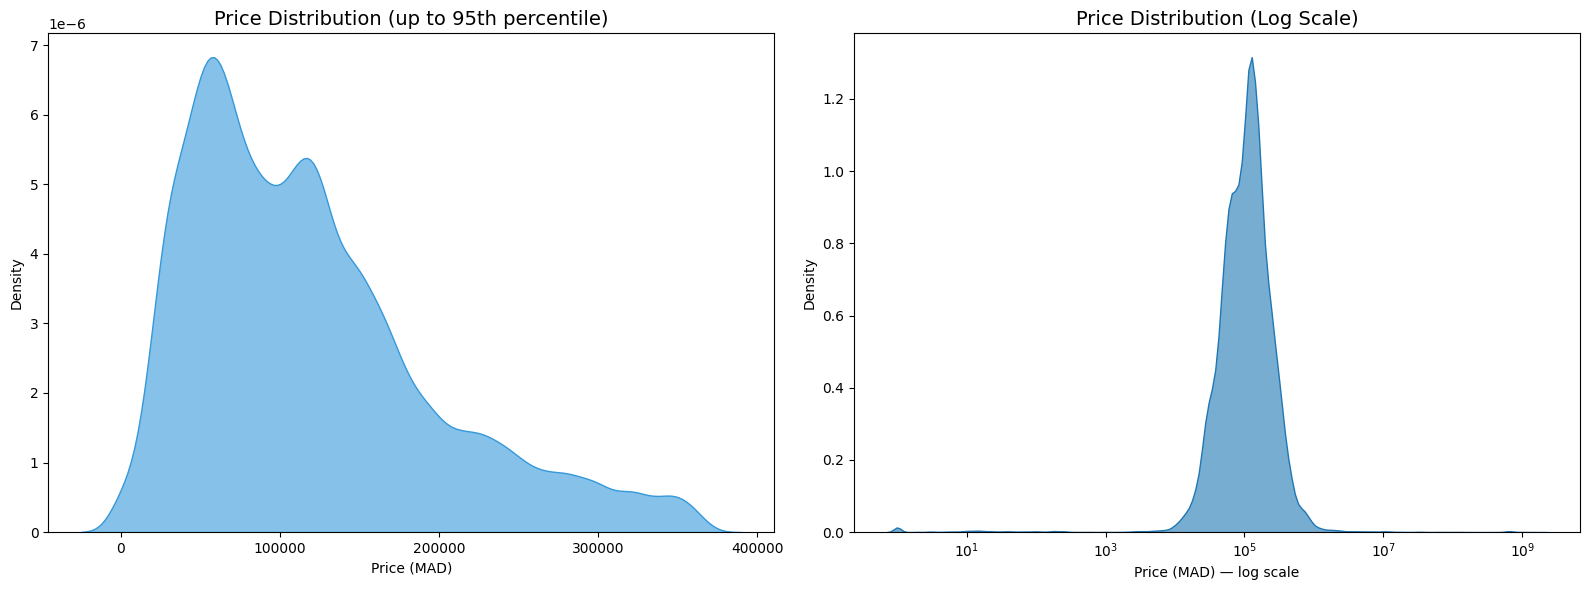

In [227]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Clipped to 95th percentile for a cleaner view
upper = df['Price'].quantile(0.95)
sns.kdeplot(data=df[df['Price'] <= upper], x='Price', fill=True, color='#3498db', alpha=0.6, ax=axes[0])
axes[0].set_title('Price Distribution (up to 95th percentile)', fontsize=14)
axes[0].set_xlabel('Price (MAD)')

# Right: Log scale to see the full range
sns.kdeplot(data=df, x='Price', fill=True, color='#1f77b4', alpha=0.6, ax=axes[1], log_scale=True)
axes[1].set_title('Price Distribution (Log Scale)', fontsize=14)
axes[1].set_xlabel('Price (MAD) — log scale')

plt.tight_layout()
plt.show()


2. What is the average/median price by Brand? — Which brands command the highest prices?


In [228]:
df.groupby("Brand").agg({"Price": "median"}).sort_values("Price", ascending=False)

,Price
Brand,
Bentley,619999.0
Lexus,459000.0
Tesla,455000.0
Hummer,422500.0
Cupra,392500.0
...,...
Geely,35500.0
BYD,33000.0
Chery,32500.0


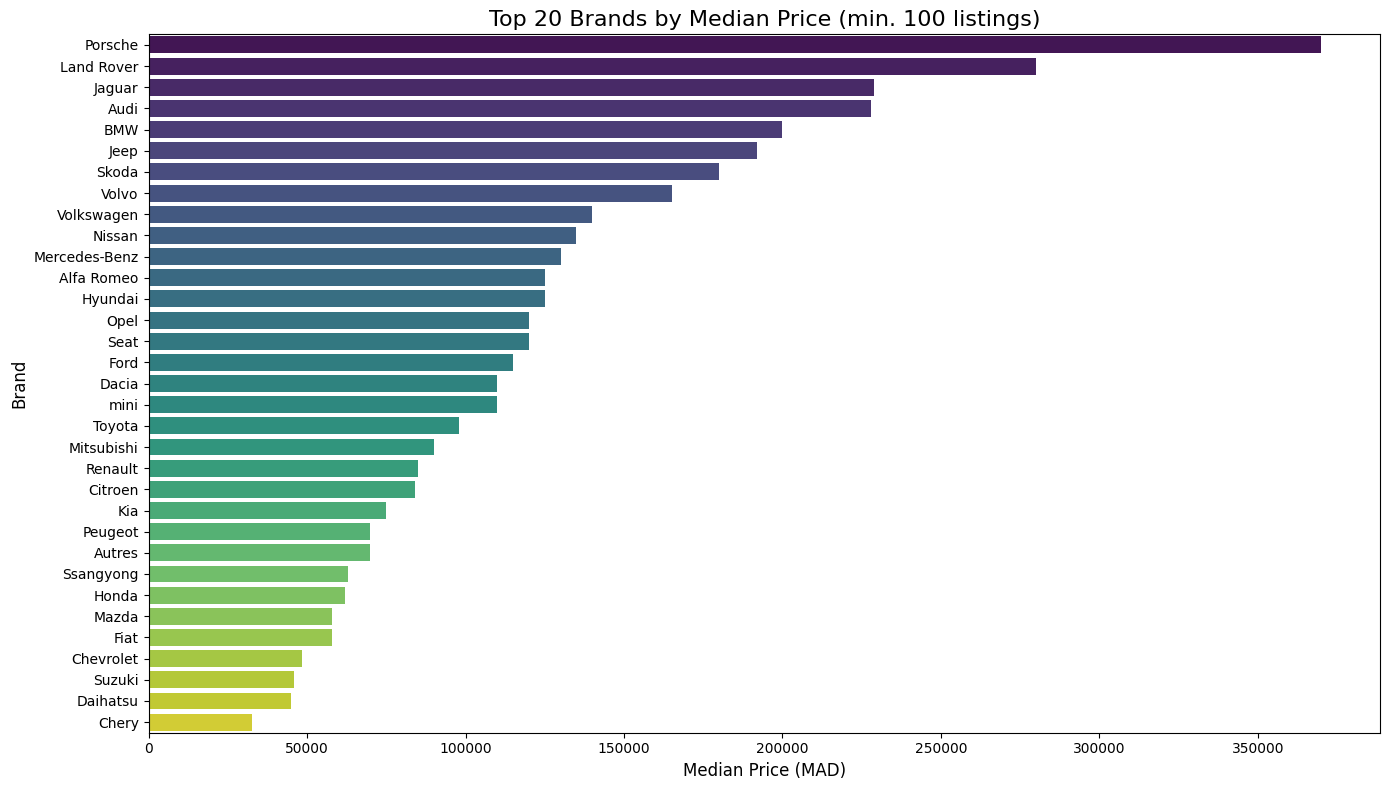

In [229]:
# Only include brands with at least 100 listings for reliability
brand_counts = df['Brand'].value_counts()
popular_brands = brand_counts[brand_counts >= 100].index
df_popular = df[df['Brand'].isin(popular_brands)]

# Use MEDIAN instead of mean — robust to outliers
median_price = df_popular.groupby('Brand')['Price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(x=median_price.values, y=median_price.index, hue=median_price.index, legend=False, palette='viridis', ax=ax)
ax.set_title('Top 20 Brands by Median Price (min. 100 listings)', fontsize=16)
ax.set_xlabel('Median Price (MAD)', fontsize=12)
ax.set_ylabel('Brand', fontsize=12)
plt.tight_layout()
plt.show()


3. How does car age (Year) affect price ? (Intuitively, the older the car, the lower the price is)

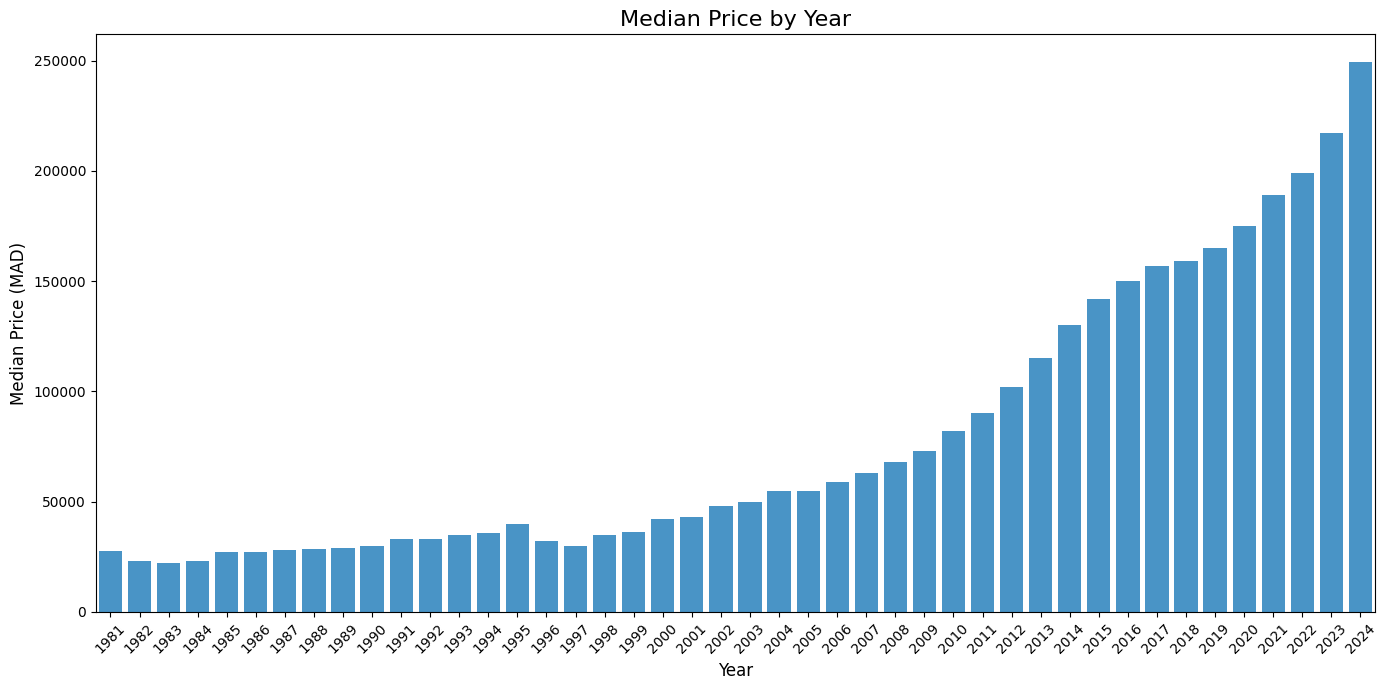

In [230]:
median_by_year = df.groupby('Year')['Price'].median().reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=median_by_year, x='Year', y='Price', color='#3498db', ax=ax)
ax.set_title('Median Price by Year', fontsize=16)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Median Price (MAD)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


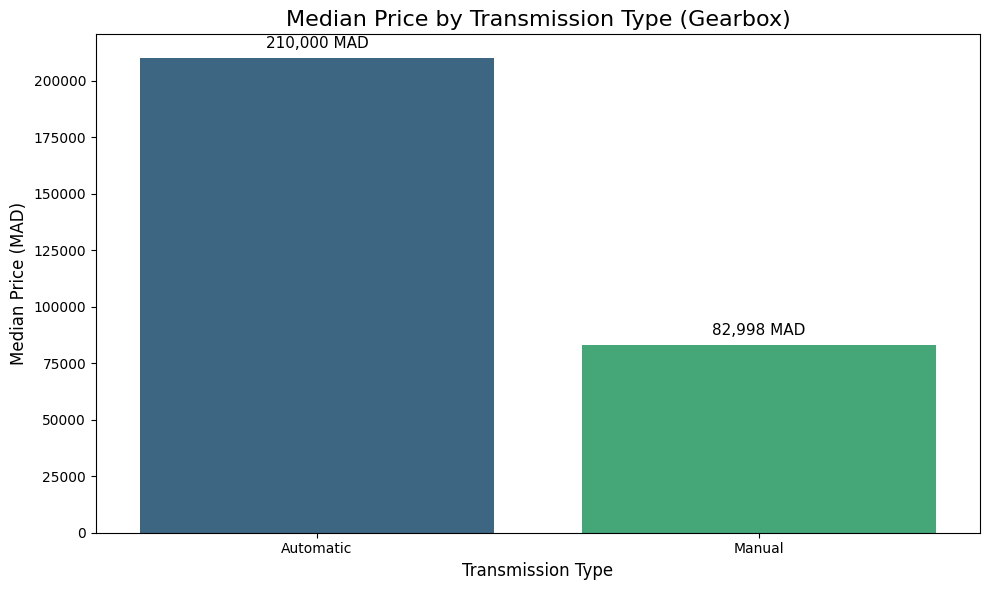

In [231]:
# Calculate median price per gearbox type
median_price_by_gearbox = df.groupby('Gearbox')['Price'].median().reset_index()

# Sort the values so the plot is ordered from highest to lowest price
median_price_by_gearbox = median_price_by_gearbox.sort_values(by='Price', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=median_price_by_gearbox, x='Gearbox', y='Price', hue='Gearbox', legend=False, palette='viridis', ax=ax)

ax.set_title('Median Price by Transmission Type (Gearbox)', fontsize=16)
ax.set_xlabel('Transmission Type', fontsize=12)
ax.set_ylabel('Median Price (MAD)', fontsize=12)

# Add exact value labels on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f} MAD", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


4. How does Mileage impact Price ? Do higher-mileage cars sell for significantly less? (Intuitively, the answer is **yes**)

In [232]:
## TO DO LATER

6. Does Condition rating correlate with Price as expected? — Fair < Good < Very Good < Excellent? (We should expect that cars in **Very Good** or **Excellent** conditions to command a higher price)

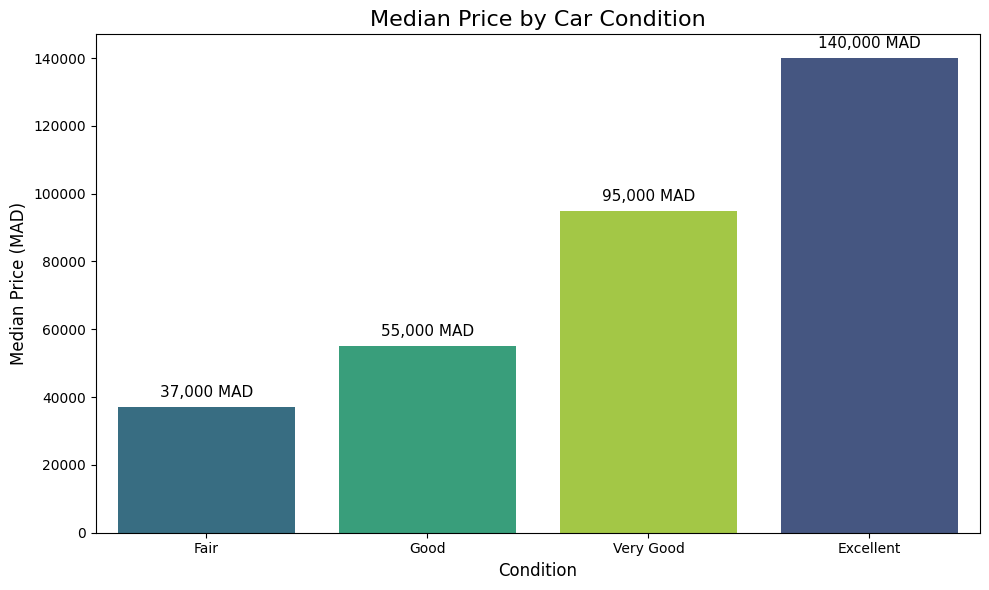

In [233]:
# Calculate median price per condition
median_price_by_condition = df.groupby('Condition')['Price'].median().reset_index()

# Define the logical order of conditions
condition_order = ['Fair', 'Good', 'Very Good', 'Excellent']

fig, ax = plt.subplots(figsize=(10, 6))

# Plot, enforcing the order
sns.barplot(
    data=median_price_by_condition, 
    x='Condition', 
    y='Price', 
    hue='Condition',
    order=condition_order, 
    palette='viridis', 
    ax=ax
)

ax.set_title('Median Price by Car Condition', fontsize=16)
ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Median Price (MAD)', fontsize=12)

# Add exact value labels on top of the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f} MAD", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


### Market Composition
7. What are the most common Brands and Models? — Market share distribution.

In [234]:
df.Brand.value_counts()


Brand
Renault           8848
Volkswagen        8665
Peugeot           6688
Dacia             5999
Mercedes-Benz     5127
                  ... 
AC                   3
Masey Ferguson       3
UFO                  3
GMC                  3
Force                2
Name: count, Length: 63, dtype: int64

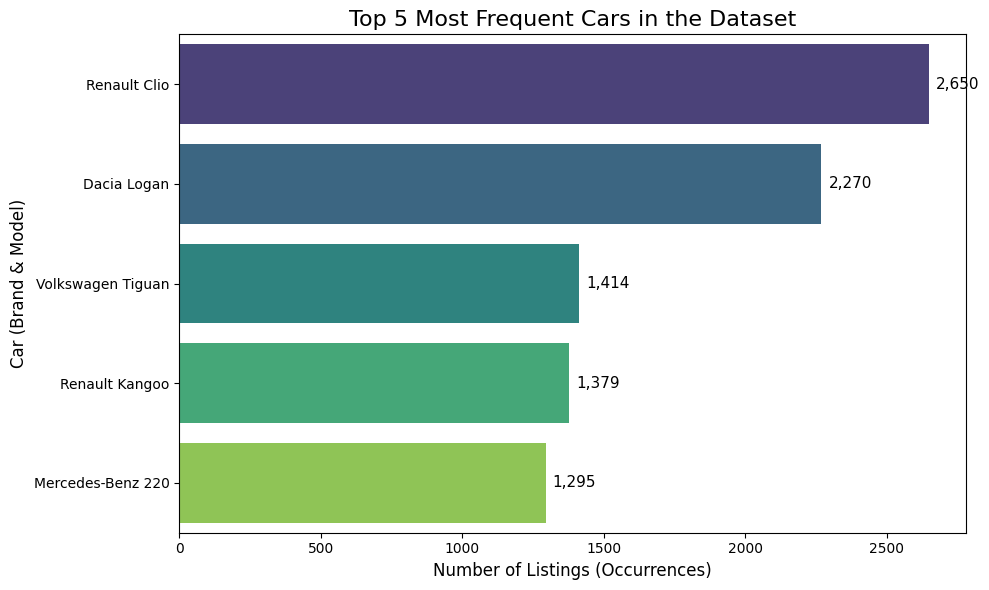

In [235]:
# 1. Create a combined "Brand Model" column for a clearer label
df_plot = df.copy()
df_plot['Car'] = df_plot['Brand'] + ' ' + df_plot['Model']

# 2. Get the top 5 most frequent cars
top_5_cars = df_plot['Car'].value_counts().head(5).reset_index()
top_5_cars.columns = ['Car', 'Count']

# 3. Create the Bar Plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top_5_cars,
    x='Count',
    y='Car',
    hue='Car',
    palette='viridis',
    ax=ax
)

ax.set_title('Top 5 Most Frequent Cars in the Dataset', fontsize=16)
ax.set_xlabel('Number of Listings (Occurrences)', fontsize=12)
ax.set_ylabel('Car (Brand & Model)', fontsize=12)

# Add exact counts next to the bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}", 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                fontsize=11, color='black', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()


8. What is the distribution of car Years? — Is the market dominated by recent or older cars?

In [236]:
## Let's suppose that newer cars are from 2020 and onward
## Let's split the dataset to figure out how many new cars we have
years_list = list(df['Year'].unique())
years_list.sort()
new_cars = df[df['Year'] >= 2020]
old_cars = df[df['Year'] < 2020]
print("Number of new cars:", len(new_cars))
print("Number of old cars:", len(old_cars))
old_cars_percentage = len(old_cars) / len(df)
print(f"The number of old cars represents {100 * old_cars_percentage:.2f}% of all cars!")

Number of new cars: 11954
Number of old cars: 60285
The number of old cars represents 83.45% of all cars!


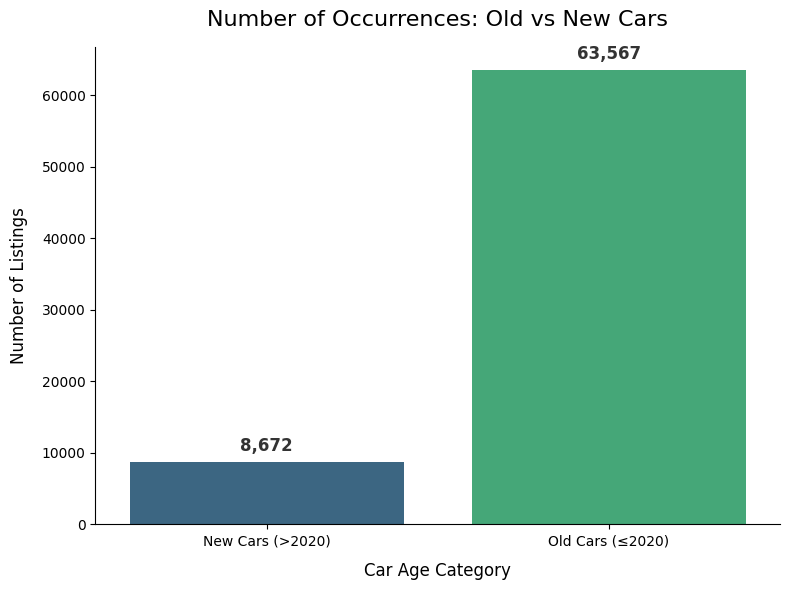

In [237]:
new_cars = df[df['Year'] > 2020]
old_cars = df[df['Year'] <= 2020]

counts = {
    'Category': ['New Cars (>2020)', 'Old Cars (≤2020)'],
    'Count': [new_cars.shape[0], old_cars.shape[0]]
}
df_counts = pd.DataFrame(counts)

fig, ax = plt.subplots(figsize=(8, 6))
old_palette = ['#3b82f6', '#1e3a8a']
sns.barplot(
    data=df_counts,
    x='Category',
    y='Count',
    hue='Category',
    palette='viridis', # Clean Blue Palette
    ax=ax
)

ax.set_title('Number of Occurrences: Old vs New Cars', fontsize=16, pad=15)
ax.set_xlabel('Car Age Category', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Listings', fontsize=12, labelpad=10)

# Add exact counts with commas for readability
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=12, color='#333333', fontweight='bold', xytext=(0, 5), textcoords='offset points')

# Remove top and right borders for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [238]:
##9. What’s the split between Manual vs. Automatic gearboxes? 
##To answer that question you need to show the count and percentage of each gearbox type.

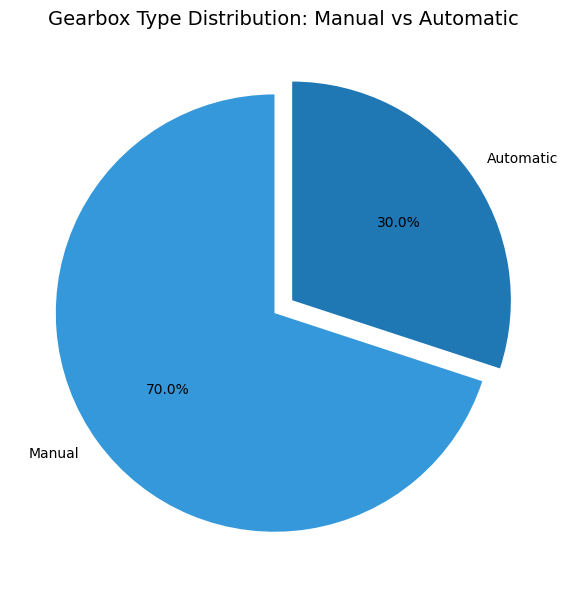

In [239]:
# Calculate the distribution of gearbox types
df['Gearbox'].value_counts(normalize=True).mul(100).round(2)

# Visualize with a simple pie chart
fig, ax = plt.subplots(figsize=(6, 6))
df['Gearbox'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#3498db', '#1f77b4'],
                                     startangle=90, explode=(0.05, 0.05), ax=ax)
ax.set_ylabel('')
ax.set_title('Gearbox Type Distribution: Manual vs Automatic', fontsize=14)
plt.tight_layout()
plt.show()

Fuel
Diesel        79.8
Petrol        19.0
Hybrid         0.9
Electrique     0.3
LPG            0.1
Name: proportion, dtype: float64


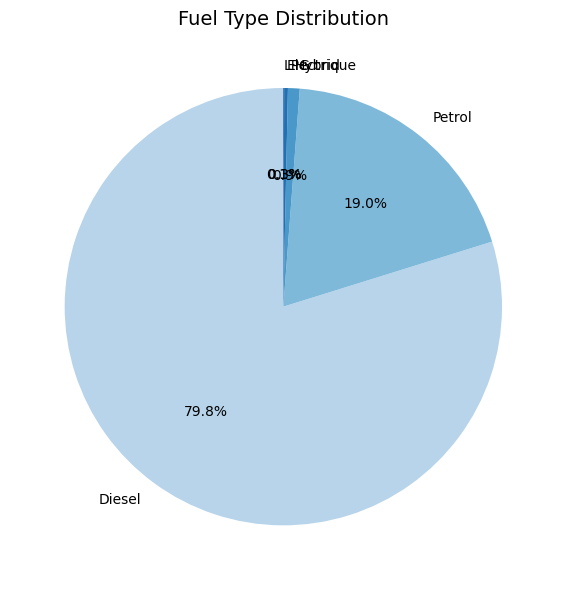

In [240]:
# 10. Fuel type distribution (Diesel vs Petrol)
fuel_counts = df['Fuel'].value_counts(normalize=True).mul(100).round(1)
print(fuel_counts)

import matplotlib.cm as cm
fig, ax = plt.subplots(figsize=(6,6))
colors = cm.Blues(np.linspace(0.3, 0.9, df['Fuel'].value_counts().shape[0]))
df['Fuel'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax, colors=colors)
ax.set_ylabel('')
ax.set_title('Fuel Type Distribution', fontsize=14)
plt.tight_layout()
plt.show()



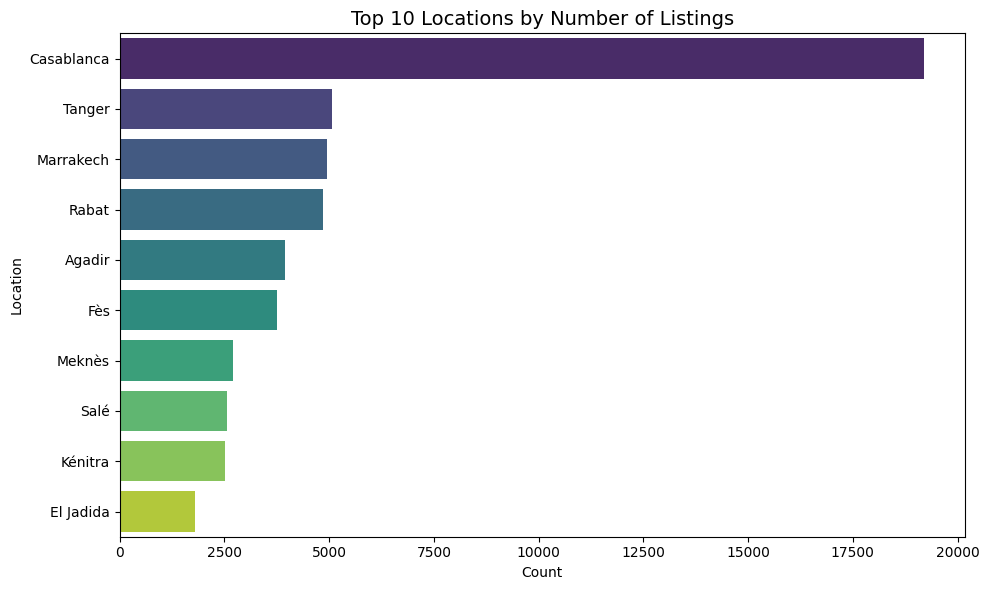

In [241]:
# Geographic insights
# 11. Locations with most listings
loc_counts = df['Location'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=loc_counts.values, y=loc_counts.index, hue=loc_counts.index, legend=False, palette='viridis', ax=ax)
ax.set_title('Top 10 Locations by Number of Listings', fontsize=14)
ax.set_xlabel('Count')
ax.set_ylabel('Location')
plt.tight_layout()
plt.show()


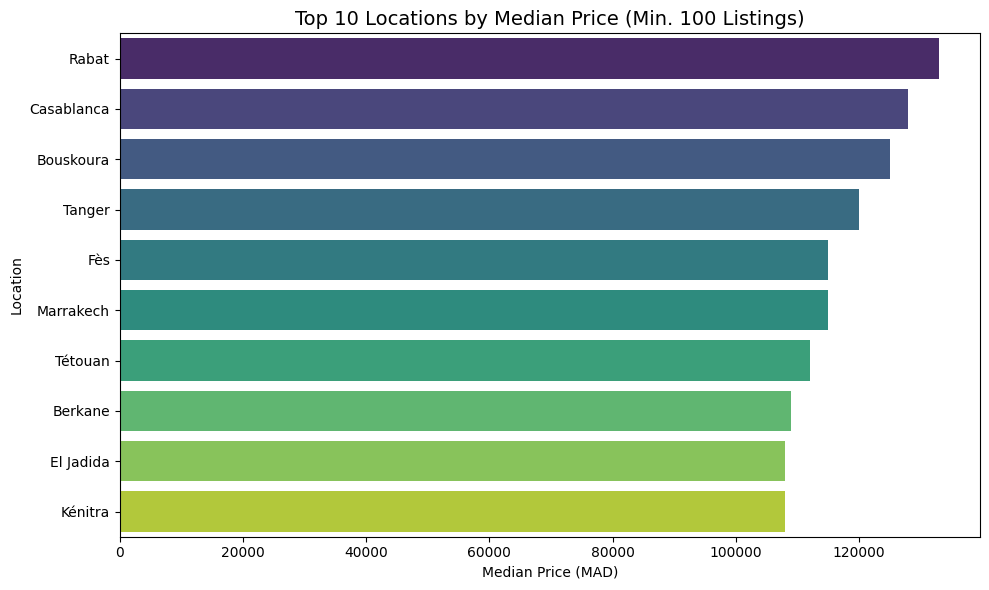

In [254]:
# 12. Price by location (median) - ONLY FOR LOCATIONS WITH >= {threshold} LISTINGS
threshold = 100
loc_counts = df['Location'].value_counts()
popular_locs = loc_counts[loc_counts >= threshold].index
df_popular_loc = df[df['Location'].isin(popular_locs)]

median_price_loc = df_popular_loc.groupby('Location')['Price'].median().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=median_price_loc.values, y=median_price_loc.index, hue=median_price_loc.index, legend=False, palette='viridis', ax=ax)
ax.set_title(f'Top 10 Locations by Median Price (Min. {threshold} Listings)', fontsize=14)
ax.set_xlabel('Median Price (MAD)')
ax.set_ylabel('Location')
plt.tight_layout()
plt.show()


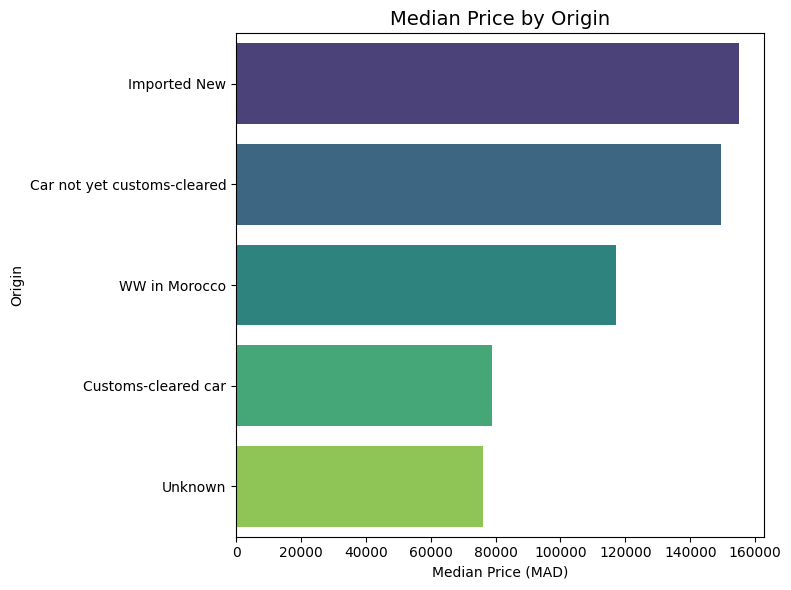

In [249]:
# 13. Origin effect on price
median_price_origin = df.groupby('Origin')['Price'].median().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,6))
sns.barplot(x=median_price_origin.values, y=median_price_origin.index, hue=median_price_origin.index, legend=False, palette='viridis', ax=ax)
ax.set_title('Median Price by Origin', fontsize=14)
ax.set_xlabel('Median Price (MAD)')
ax.set_ylabel('Origin')
plt.tight_layout()
plt.show()



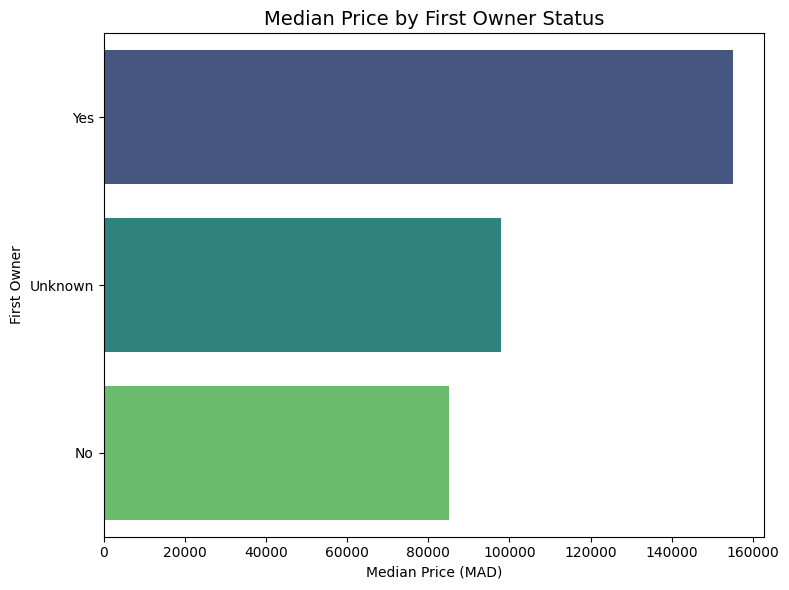

In [244]:
# 14. First Owner impact
median_price_owner = df.groupby('First Owner')['Price'].median().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,6))
sns.barplot(x=median_price_owner.values, y=median_price_owner.index, hue=median_price_owner.index, legend=False, palette='viridis', ax=ax)
ax.set_title('Median Price by First Owner Status', fontsize=14)
ax.set_xlabel('Median Price (MAD)')
ax.set_ylabel('First Owner')
plt.tight_layout()
plt.show()



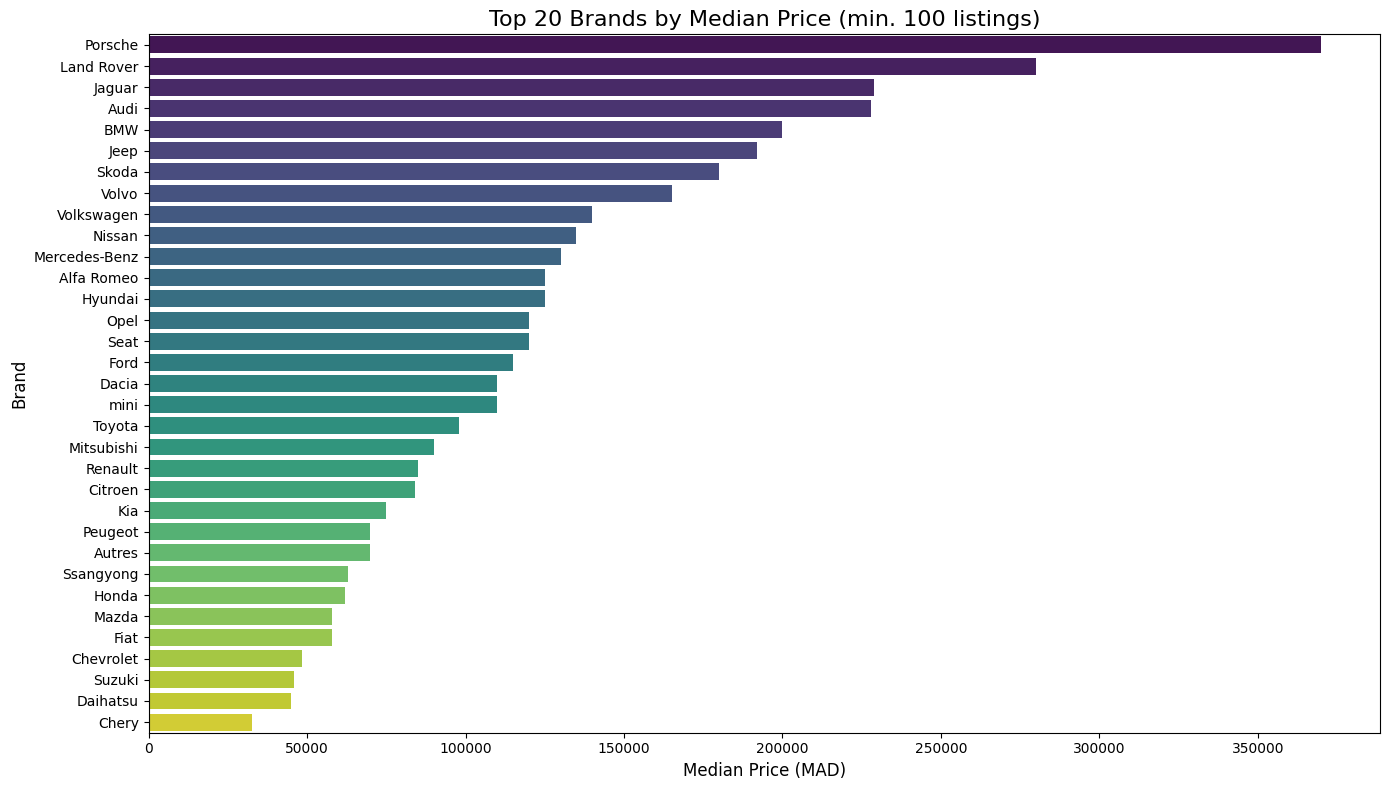

In [245]:
# Only include brands with at least 100 listings for reliability
brand_counts = df['Brand'].value_counts()
popular_brands = brand_counts[brand_counts >= 100].index
df_popular = df[df['Brand'].isin(popular_brands)]

# Use MEDIAN instead of mean — robust to outliers
median_price = df_popular.groupby('Brand')['Price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(x=median_price.values, y=median_price.index, hue=median_price.index, legend=False, palette='viridis', ax=ax)
ax.set_title('Top 20 Brands by Median Price (min. 100 listings)', fontsize=16)
ax.set_xlabel('Median Price (MAD)', fontsize=12)
ax.set_ylabel('Brand', fontsize=12)
plt.tight_layout()
plt.show()


Correlation between number of equipment features and price: -0.009


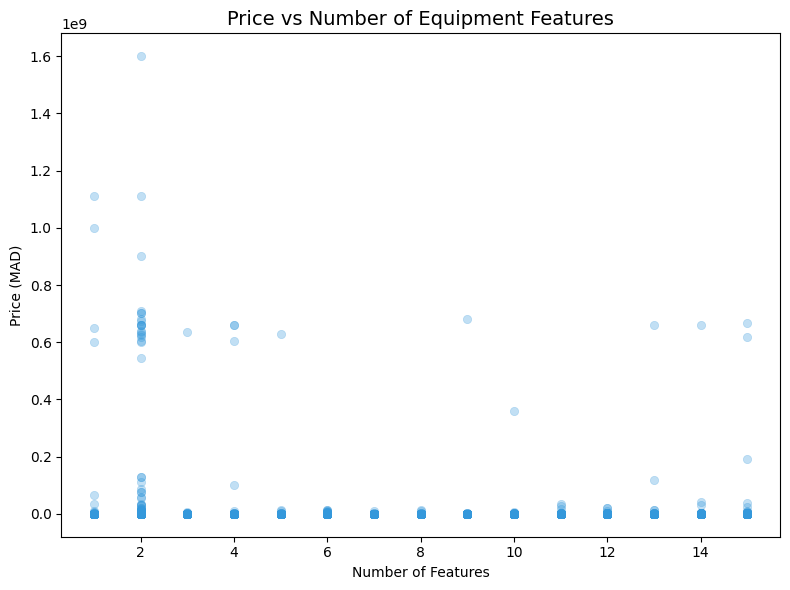

In [246]:
# 16. Correlation between number of features and price
df['num_features'] = df['Equipment'].fillna('').apply(lambda s: len([x for x in s.split(',') if x.strip()!='']))
corr = df['num_features'].corr(df['Price'])
print(f'Correlation between number of equipment features and price: {corr:.3f}')

# scatter
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df, x='num_features', y='Price', alpha=0.3, edgecolor=None, color='#3498db')
ax.set_title('Price vs Number of Equipment Features', fontsize=14)
ax.set_xlabel('Number of Features')
ax.set_ylabel('Price (MAD)')
plt.tight_layout()
plt.show()



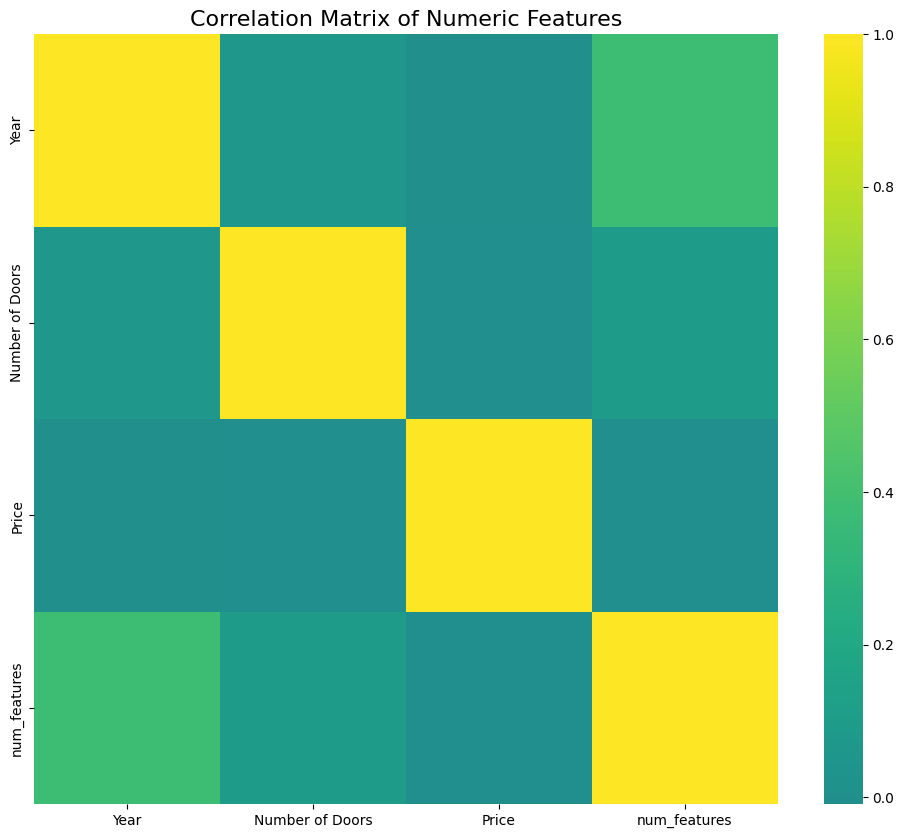

In [247]:
# 17. Correlation heatmap (numeric features)
numeric = df.select_dtypes(include=[np.number])
corr_matrix = numeric.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='viridis', center=0, annot=False)
plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()
